In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
path = "2026-02-14_14-09-33-703.csv"
df=pd.read_csv(path)
t= df.time.values
vds=df.CH1.values

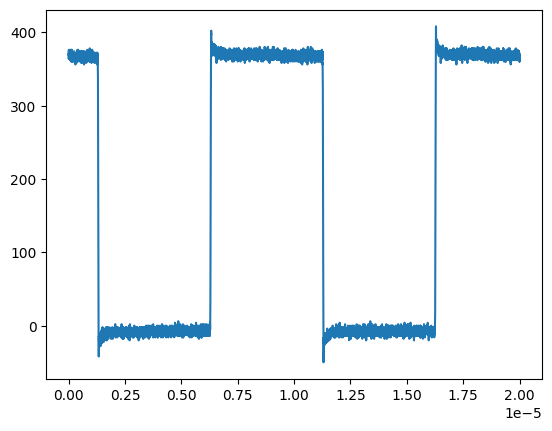

In [3]:
plt.plot(t, vds)

(-50.0, 10.0)

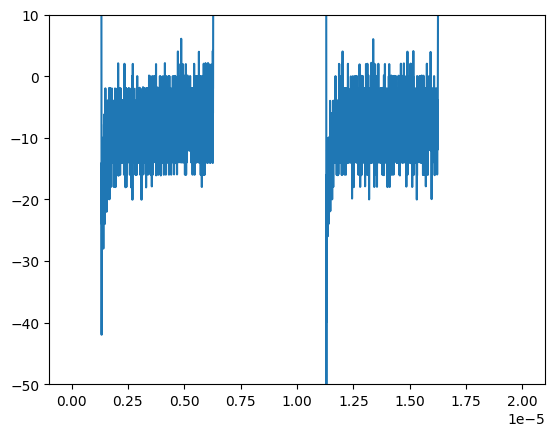

In [9]:
plt.plot(t, vds)
plt.ylim([-50,10])

In [142]:
load = [np.inf, 52.1, 36, 24.5, 12.8, 9.2]
files = ['2026-02-14_13-56-32-214',
 '2026-02-14_13-58-48-201',
 '2026-02-14_13-59-51-527',
 '2026-02-14_14-01-25-664',
 '2026-02-14_14-07-22-440',
 '2026-02-14_14-09-33-703']
vout = 48.11
Iout= []
Pout=[]
for l in load : 
    Iout .append(vout/l)
    Pout .append(vout**2/l)
Iout 

[0.0,
 0.9234165067178502,
 1.3363888888888888,
 1.963673469387755,
 3.7585937499999997,
 5.229347826086957]

In [143]:
Pout

[0.0,
 44.42556813819577,
 64.29366944444445,
 94.47233061224489,
 180.82594531249998,
 251.5839239130435]

In [60]:
from matplotlib.ticker import LinearLocator

In [145]:
files

['2026-02-14_13-56-32-214',
 '2026-02-14_13-58-48-201',
 '2026-02-14_13-59-51-527',
 '2026-02-14_14-01-25-664',
 '2026-02-14_14-07-22-440',
 '2026-02-14_14-09-33-703']

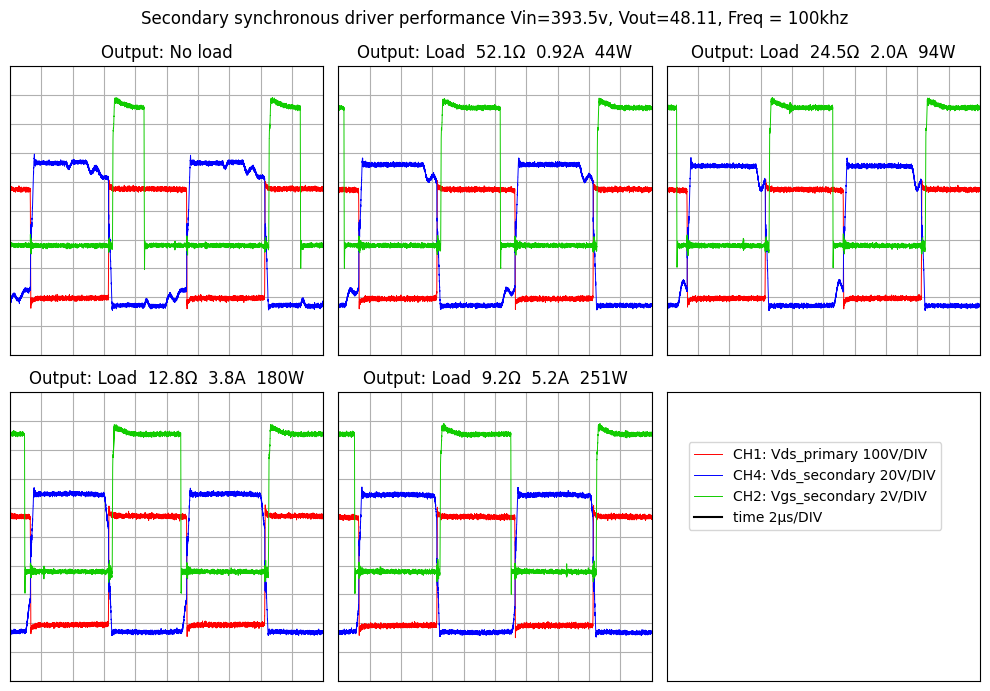

In [158]:
fig, axs = plt.subplots(2,3, figsize=(10,7))
axs = axs .flatten()

dfs=[]
k=0
for l, i, p, f in zip(load, Iout, Pout, files):
    path = f+".csv"
    df=pd.read_csv(path)
    t= df.time.values
    vds=df.CH1.values
    dfs.append(df)
    if l==36:
        #ax.plot(df.time,(df.CH2/2)+2)
        continue 
    ax=axs[k]
    ax.plot(df.time, (df.CH1/100), c="r", linewidth=0.7, 
            label= "CH1: Vds_primary 100V/DIV")
    ax.plot(df.time, (df.CH4/20), c="b", linewidth=0.7, 
            label= "CH4: Vds_secondary 20V/DIV")
    ax.plot(df.time,(df.CH2/2)+2, c="#11CC00", linewidth=0.7, 
            label= "CH2: Vgs_secondary 2V/DIV")
    ax.plot([0],[0], c="k",  label= "time 2µs/DIV")

    ax.set_ylim([-2,8])
    ax.set_xlim([0,2e-5])
    ax.grid(which="both")
    ax.xaxis.set_major_locator(LinearLocator(11))  # 10 divisions
    ax.yaxis.set_major_locator(LinearLocator(11))  # 10 divisions
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    if l != np.inf:
        title= f'Output: Load  {l}Ω  {i:.2}A  {int(p)}W'
    else: 
        title= f'Output: No load'
    ax.set_title(title)
    k=k+1
    
axs[5].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)    

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="center",
    bbox_to_anchor=(0.82, 0.3),  # (x, y) in figure coords
    ncol=1
)
fig.suptitle("Secondary synchronous driver performance Vin=393.5v, Vout=48.11, Freq = 100khz")
plt.tight_layout()
fig.savefig("SR_Performance")
